In [1]:

# SEKCJA 1: IMPORTY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import math
from scipy.fft import fft
from scipy.stats import skew, kurtosis
from scipy.signal import resample_poly

pd.set_option('future.no_silent_downcasting', True)
os.makedirs('data/intermediate', exist_ok=True)

In [2]:

# SEKCJA 2: EKSTRAKCJA CECH

def crest_factor(x):
    return np.max(x) / np.mean(x)

def rms(x):
    return np.sqrt(np.mean(x**2))

def peak_to_peak(x):
    return np.ptp(x)

def amplitude_spectrum(signal_data, fs):
    N = len(signal_data)
    freq_axis = np.fft.fftfreq(N, 1/fs)[:N // 2]
    spectrum = np.abs(fft(signal_data))[:N // 2]
    return freq_axis, spectrum

def frequency_domain_features(signal_data, fs):
    freq_axis, spectrum = amplitude_spectrum(signal_data, fs)
    features = {}
    if np.sum(spectrum) == 0:
        return features
    features["Frequency Center"] = np.sum(freq_axis * spectrum) / np.sum(spectrum)
    features["Spectrum Area"] = np.sum(spectrum)
    rotation_speed = signal_data.mean()
    features["Amp @ 1x RPM"] = spectrum[np.argmin(np.abs(freq_axis - rotation_speed))]
    features["Amp @ 2x RPM"] = spectrum[np.argmin(np.abs(freq_axis - 2 * rotation_speed))]
    features["Amp @ 3x RPM"] = spectrum[np.argmin(np.abs(freq_axis - 3 * rotation_speed))]
    return features

def add_stats(df, fs=20000):
    df_temp = df.copy()
    time_features = {
        'CURRENT (A)': ['mean', 'std', 'max', rms, peak_to_peak, skew, kurtosis, crest_factor],
        'ROTO (RPM)': ['mean', 'std', 'max', rms, peak_to_peak, skew, kurtosis, crest_factor]
    }
    df_stats = df_temp.groupby('Experiment ID').agg(time_features)
    df_stats.columns = [f'{col[0]} {col[1]}' for col in df_stats.columns]
    
    freq_feature_list = []
    for exp_id, group in df_temp.groupby('Experiment ID'):
        c_freq = frequency_domain_features(group['CURRENT (A)'].values, fs)
        r_freq = frequency_domain_features(group['ROTO (RPM)'].values, fs)
        
        f_feat = {f'CURRENT (A) {k}': v for k, v in c_freq.items()}
        f_feat.update({f'ROTO (RPM) {k}': v for k, v in r_freq.items()})
        freq_feature_list.append([exp_id] + list(f_feat.values()))
        
    freq_df = pd.DataFrame(freq_feature_list, columns=['Experiment ID'] + list(f_feat.keys()))
    return df_stats.reset_index().merge(freq_df, on='Experiment ID', how='left')

In [3]:

# SEKCJA 3: PRZETWARZANIE SYGNAŁÓW I RESAMPLING

def rescale_current(df, curr_column):
    df.loc[:, 'CURRENT (A)'] = (df[curr_column] - 2.5) * 20 / 2.5
    return df

def calculate_rpm(df, signal_col, time_col, threshold=4.0, debounce_val=3):
    df = df.sort_values(time_col).reset_index(drop=True)
    is_above = df[signal_col] > threshold
    raw_edges = df.index[is_above & ~is_above.shift(1).fillna(False)]
    raw_edge_times = df.loc[raw_edges, time_col]
    valid_mask = raw_edge_times.diff().fillna(float('inf')) > debounce_val * 0.00005
    valid_edge_times = raw_edge_times[valid_mask]
    delta_t = valid_edge_times.diff()
    instant_rpm = 60 / delta_t
    df['ROTO (RPM)'] = pd.Series(instant_rpm, index=valid_edge_times.index)
    df['ROTO (RPM)'] = df['ROTO (RPM)'].ffill().fillna(0)
    return df

def find_stable_region(df, time_col, rpm_col='ROTO (RPM)', leeway=1000, window_size=50):
    valid_df = df[df[rpm_col] > 0].copy()
    rolling_max = valid_df[rpm_col].rolling(window=window_size, center=True).max()
    rolling_min = valid_df[rpm_col].rolling(window=window_size, center=True).min()
    valid_df['is_stable'] = (rolling_max - rolling_min) <= leeway
    valid_df['block_id'] = (~valid_df['is_stable']).cumsum()
    stable_only = valid_df[valid_df['is_stable']]
    if stable_only.empty:
        return 0.0, df[time_col].max()
    longest_block_id = stable_only['block_id'].value_counts().idxmax()
    longest_block = stable_only[stable_only['block_id'] == longest_block_id]
    return longest_block[time_col].min(), longest_block[time_col].max()

def apply_signal_resampling(df, original_fs, target_fs, columns, time_col):
    if original_fs == target_fs:
        return df
    gcd = math.gcd(original_fs, target_fs)
    up, down = target_fs // gcd, original_fs // gcd
    resampled_data = {}
    for col in columns:
        resampled_data[col] = resample_poly(df[col].values, up, down)
    new_n = len(resampled_data[columns[0]])
    resampled_data[time_col] = np.arange(new_n) / target_fs + df[time_col].iloc[0]
    return pd.DataFrame(resampled_data)

def get_samples(df, window_size, sampling_rate, time_col, name, start_time=0.0, stop_time=None):
    if stop_time is None:
        stop_time = df[time_col].max()
    temp_df = df[(df[time_col] >= start_time) & (df[time_col] <= stop_time)].copy()
    sampled_dfs = []
    points_per_window = int(window_size * sampling_rate)
    total_groups = len(temp_df) // points_per_window
    for group in range(total_groups):
        start_p, end_p = group * points_per_window, (group + 1) * points_per_window
        group_df = temp_df.iloc[start_p:end_p].copy()
        group_df['Experiment ID'] = group
        group_df[time_col] -= group_df[time_col].min()
        sampled_dfs.append(group_df)
    dfs_concat = pd.concat(sampled_dfs, ignore_index=True)
    dfs_concat.to_csv(f'data/intermediate/{name}.csv', index=False)
    return dfs_concat

In [14]:

# SEKCJA 4: ZAPIS DO PLIKU

ORIGINAL_FS = 20000
TARGET_FS = 10000
window_size = 0.8
time_col = 'Measurement time[s]'

files = [f for f in glob.glob('*.[Cc][Ss][Vv]') if f != 'final_features_dataset.csv']
final_df = pd.DataFrame()

print(f"--- START. Oryginał: {ORIGINAL_FS}Hz -> Test: {TARGET_FS}Hz ---")

for i, filename in enumerate(files):
    try:
        df = pd.read_csv(filename, skiprows=6, delimiter=';', decimal=',', index_col=False)
        df = df.dropna(axis=1, how='all')
        df = rescale_current(df, 'curr_1 [V]')
        df = calculate_rpm(df, 'omega_digital [V]', time_col)

        start_t, stop_t = find_stable_region(df, time_col, 'ROTO (RPM)', leeway=1000)
        df_stable = df[(df[time_col] >= start_t) & (df[time_col] <= stop_t)].copy()

        cols_to_resample = ['CURRENT (A)', 'ROTO (RPM)']
        df_resampled = apply_signal_resampling(df_stable, ORIGINAL_FS, TARGET_FS, cols_to_resample, time_col)

        test = get_samples(df_resampled, window_size, TARGET_FS, time_col, filename, 
                           df_resampled[time_col].min(), df_resampled[time_col].max())

        if test is not None and not test.empty:
            current_stats = add_stats(test, fs=TARGET_FS)
            current_stats = current_stats[current_stats['Experiment ID'] != 0]
            if not current_stats.empty:
                current_stats['Source_File'] = filename
                final_df = pd.concat([final_df, current_stats], ignore_index=True)
                print(f"[{i+1}/{len(files)}] {filename} -> OK")
    except Exception as e:
        print(f"[{i+1}/{len(files)}] {filename} -> BŁĄD: {e}")

final_df.to_csv('features_resampled_10kHz.csv', index=False)
print(f"--- ZAKOŃCZONO. Plik wyjściowy: features_resampled_10kHz.csv ---")

--- START. Oryginał: 20000Hz -> Test: 10000Hz ---
[1/5] NOWY-trytytka-01.CSV -> OK
[2/5] NOWY-trytytka-02.CSV -> OK
[3/5] NOWY-trytytka-03.CSV -> OK
[4/5] NOWY-trytytka-04.CSV -> OK
[5/5] NOWY-trytytka-05.CSV -> OK
--- ZAKOŃCZONO. Plik wyjściowy: features_resampled_10kHz.csv ---


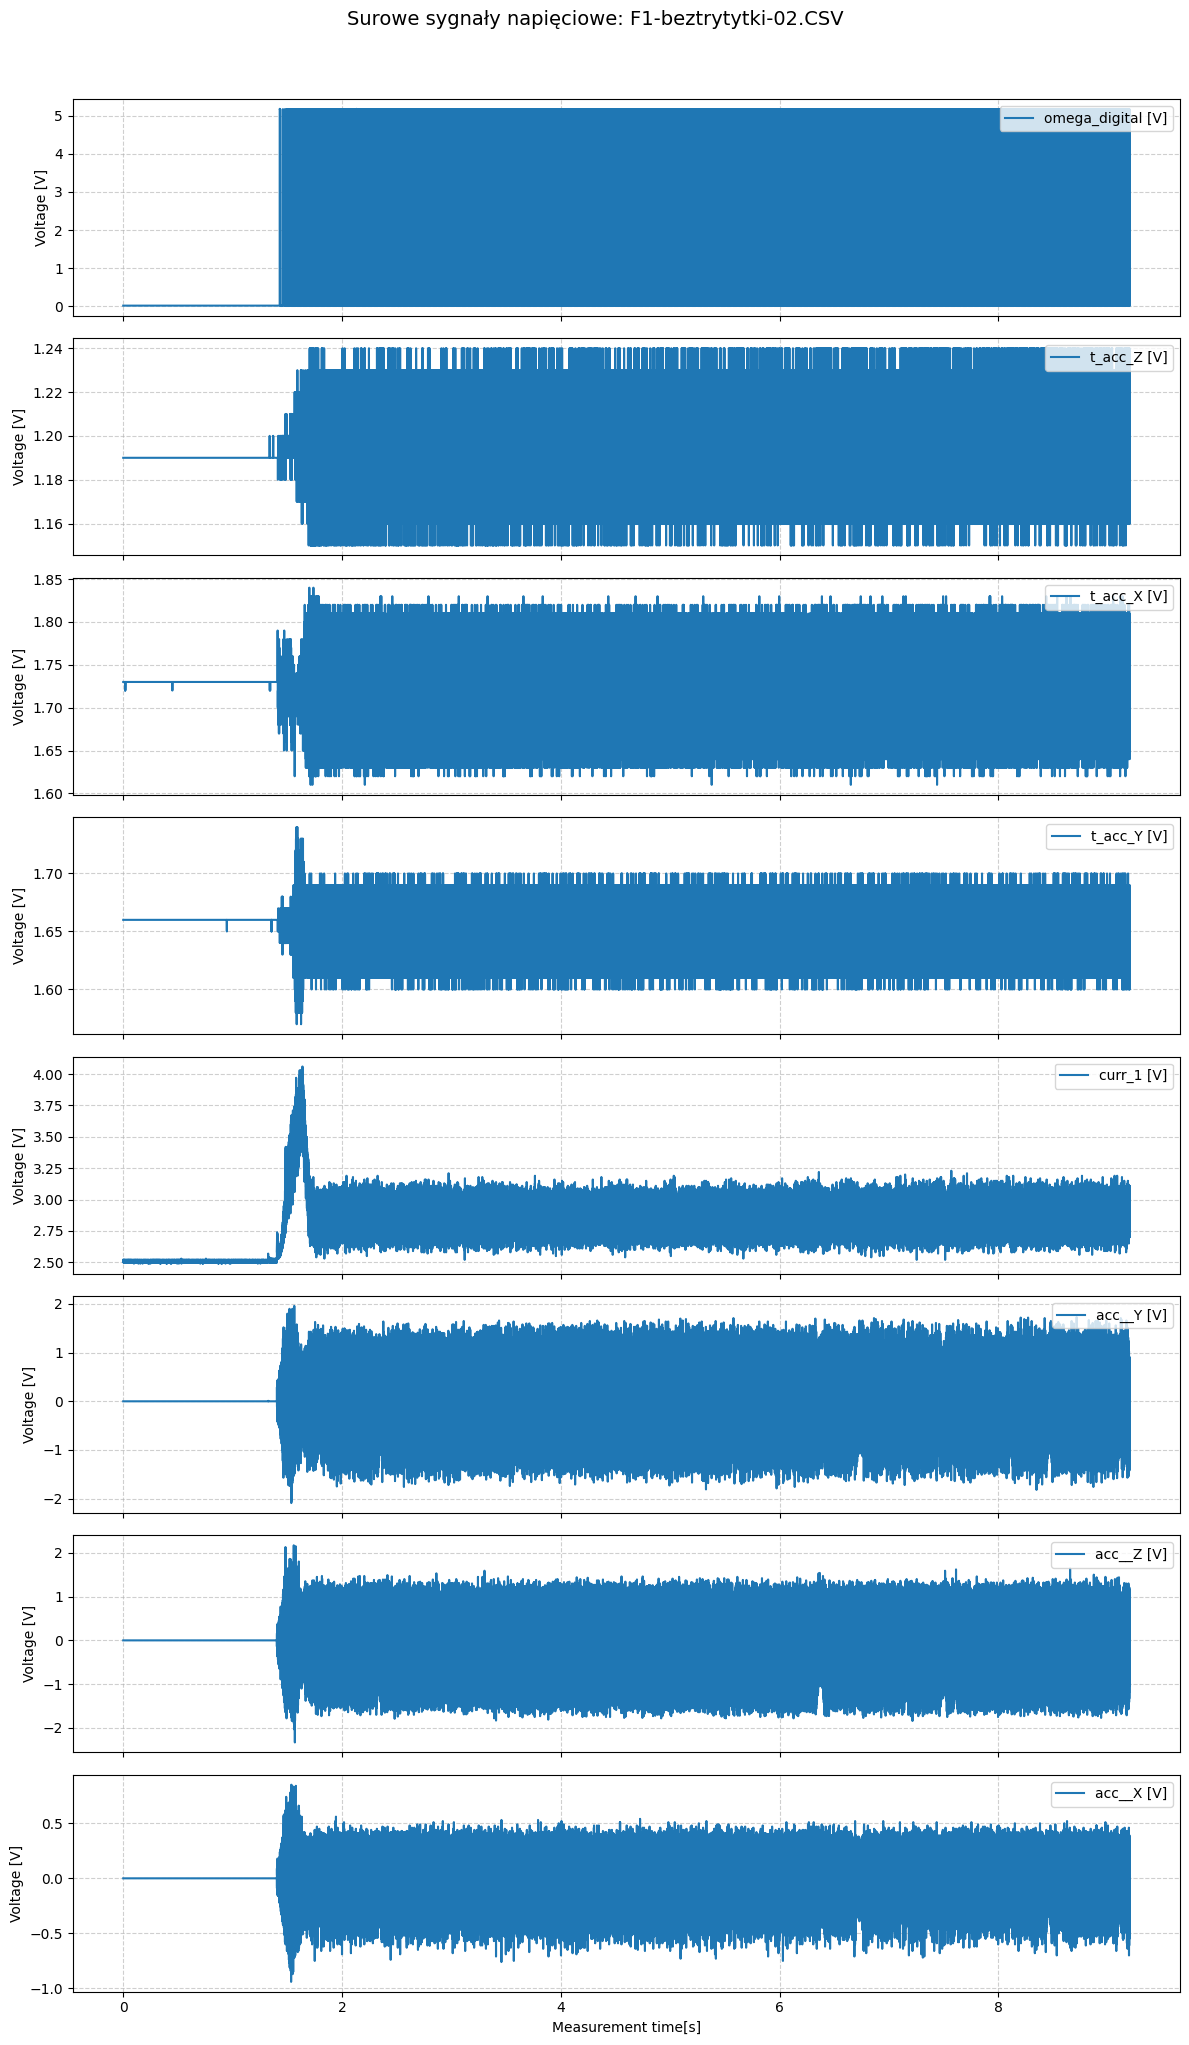

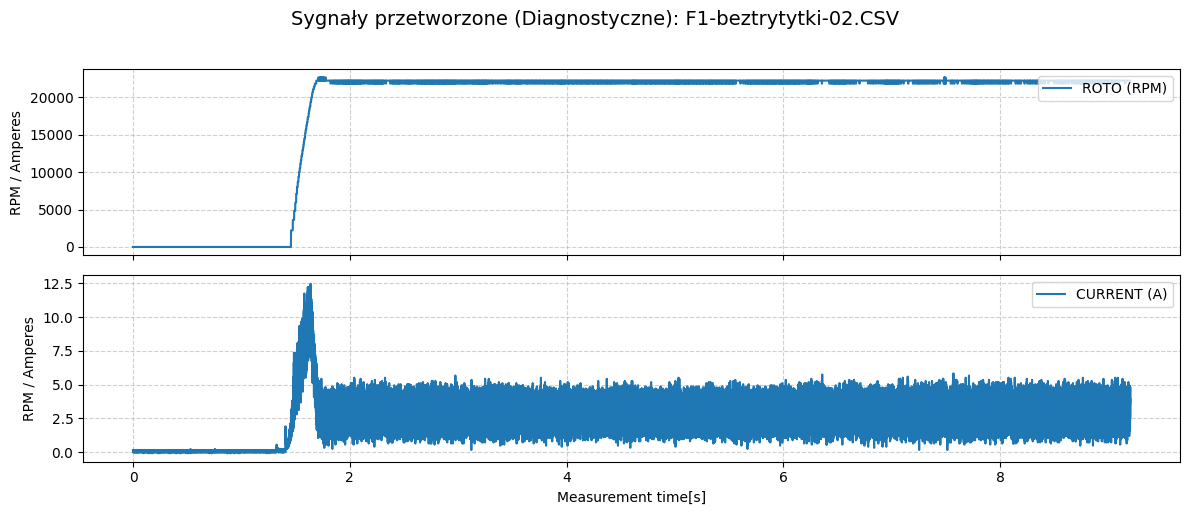

In [5]:

# SEKCJA 5: WIZUALIZACJE

filename_plot = 'F1-beztrytytki-02.CSV'

if os.path.exists(filename_plot):
    df_plot = pd.read_csv(filename_plot, skiprows=6, delimiter=';', decimal=',', index_col=False)
    df_plot = df_plot.dropna(axis=1, how='all')
    if 'curr_2 [V]' in df_plot.columns:
        df_plot.drop(columns=['curr_2 [V]'], inplace=True)
    
    df_plot = calculate_rpm(df_plot, 'omega_digital [V]', time_col)
    df_plot = rescale_current(df_plot, 'curr_1 [V]')

    plot_configs = [
        ("Surowe sygnały napięciowe", [c for c in df_plot.columns if ' [V]' in c], "Voltage [V]"),
        ("Sygnały przetworzone (Diagnostyczne)", ['ROTO (RPM)', 'CURRENT (A)'], "RPM / Amperes")
    ]

    for title, cols, ylabel in plot_configs:
        fig, axes = plt.subplots(len(cols), 1, figsize=(12, 2.5 * len(cols)), sharex=True)
        if len(cols) == 1: axes = [axes]
        
        for ax, col in zip(axes, cols):
            ax.plot(df_plot[time_col], df_plot[col], color='tab:blue', label=col)
            ax.set_ylabel(ylabel)
            ax.legend(loc='upper right')
            ax.grid(True, linestyle='--', alpha=0.6)
        
        axes[-1].set_xlabel(time_col)
        plt.suptitle(f"{title}: {filename_plot}", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print(f"Informacja: Plik {filename_plot} nie został znaleziony - pominięto wizualizację.")